In [5]:
pip install sounddevice soundfile librosa pretty_midi numpy

In [6]:
!apt-get update -qq
!apt-get install -y portaudio19-dev
!pip install sounddevice soundfile librosa pretty_midi

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
portaudio19-dev is already the newest version (19.6.0-1.2build3).
0 upgraded, 0 newly installed, 0 to remove and 64 not upgraded.
^C


In [2]:
!pip install -q librosa soundfile pretty_midi numpy

In [71]:
from IPython.display import Javascript, display
from google.colab.output import eval_js
from base64 import b64decode
import subprocess
import librosa
import numpy as np


# ============================================================
# 1. RECORD HUMMING
# ============================================================

display(Javascript("""
async function recordAudio() {

    const stream = await navigator.mediaDevices.getUserMedia({
        audio: true
    });

    const recorder = new MediaRecorder(stream);
    const chunks = [];

    recorder.ondataavailable = event => {
        if (event.data.size > 0) {
            chunks.push(event.data);
        }
    };

    recorder.start();

    console.log("Recording...");

    // 30 seconds
    await new Promise(resolve =>
        setTimeout(resolve, 30000)
    );

    recorder.stop();

    await new Promise(resolve =>
        recorder.onstop = resolve
    );

    stream.getTracks().forEach(
        track => track.stop()
    );

    const blob = new Blob(
        chunks,
        {type: "audio/webm"}
    );

    return await new Promise((resolve, reject) => {

        const reader = new FileReader();

        reader.onloadend = () => {

            const base64 =
                reader.result.split(",")[1];

            resolve(base64);
        };

        reader.onerror = reject;

        reader.readAsDataURL(blob);
    });
}
"""))


print("🎤 Recording for 30 seconds...")

audio_data = eval_js("recordAudio()")


# ============================================================
# 2. SAVE RECORDING
# ============================================================

with open("humming.webm", "wb") as f:
    f.write(b64decode(audio_data))

print("✅ Recording saved!")


# ============================================================
# 3. CONVERT WEBM → WAV
# ============================================================

subprocess.run([
    "ffmpeg",
    "-y",
    "-i", "humming.webm",
    "-ar", "16000",
    "-ac", "1",
    "humming.wav"
], stdout=subprocess.PIPE, stderr=subprocess.PIPE)

print("✅ humming.wav created!")


# ============================================================
# 4. LOAD AUDIO
# ============================================================

audio, sr = librosa.load(
    "humming.wav",
    sr=16000,
    mono=True
)

print(
    f"🎵 Audio duration: {len(audio) / sr:.2f} seconds"
)


# ============================================================
# 5. PITCH DETECTION
# ============================================================

HOP_LENGTH = 128
FRAME_LENGTH = 2048

f0, voiced_flag, voiced_probs = librosa.pyin(

    audio,

    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C6"),

    sr=sr,

    frame_length=FRAME_LENGTH,
    hop_length=HOP_LENGTH,

    max_transition_rate=35.92,

    fill_na=np.nan
)


# ============================================================
# 6. CREATE CORRECT TIME AXIS
# ============================================================

times = (
    np.arange(len(f0))
    * HOP_LENGTH
    / sr
)


# ============================================================
# 7. FREQUENCY → MIDI
# ============================================================

midi = np.full(
    len(f0),
    np.nan
)

valid = np.isfinite(f0)

midi[valid] = librosa.hz_to_midi(
    f0[valid]
)


# ============================================================
# 8. MEDIAN SMOOTHING
# ============================================================

def median_smooth(values, window=9):

    result = values.copy()

    half = window // 2

    for i in range(len(values)):

        start = max(
            0,
            i - half
        )

        end = min(
            len(values),
            i + half + 1
        )

        section = values[start:end]

        section = section[
            np.isfinite(section)
        ]

        if len(section) > 0:

            result[i] = np.median(
                section
            )

    return result


midi_smooth = median_smooth(
    midi,
    window=9
)


# ============================================================
# 9. SNAP TO REAL PIANO NOTES
# ============================================================

midi_quantized = np.full(
    len(midi_smooth),
    np.nan
)

valid = np.isfinite(midi_smooth)

midi_quantized[valid] = np.round(
    midi_smooth[valid]
)


# ============================================================
# 10. GROUP CONTINUOUS NOTES
# ============================================================

notes = []

current_note = None
start_time = None


for i in range(
    len(midi_quantized)
):

    note = midi_quantized[i]
    time = times[i]


    # --------------------------------
    # No pitch
    # --------------------------------

    if np.isnan(note):

        if current_note is not None:

            notes.append(
                (
                    start_time,
                    time,
                    current_note
                )
            )

            current_note = None
            start_time = None

        continue


    # --------------------------------
    # First detected note
    # --------------------------------

    if current_note is None:

        current_note = note
        start_time = time

        continue


    # --------------------------------
    # Same note
    # --------------------------------

    if note == current_note:

        continue


    # --------------------------------
    # Pitch changed
    # --------------------------------

    notes.append(
        (
            start_time,
            time,
            current_note
        )
    )

    current_note = note
    start_time = time


# Add final note

if current_note is not None:

    notes.append(
        (
            start_time,
            times[-1],
            current_note
        )
    )


# ============================================================
# 11. REMOVE VERY SHORT NOTES
# ============================================================

MIN_DURATION = 0.18

notes = [

    n for n in notes

    if (
        n[1] - n[0]
        >= MIN_DURATION
    )

]


# ============================================================
# 12. MERGE NEARBY IDENTICAL NOTES
# ============================================================

MERGE_GAP = 0.12

merged = []


for start, end, pitch in notes:

    if len(merged) == 0:

        merged.append(
            [start, end, pitch]
        )

        continue


    previous = merged[-1]

    previous_end = previous[1]
    previous_pitch = previous[2]

    gap = start - previous_end


    if (
        pitch == previous_pitch
        and gap <= MERGE_GAP
    ):

        # Extend previous note

        previous[1] = end

    else:

        merged.append(
            [start, end, pitch]
        )


notes = merged


# ============================================================
# 13. MIDI → NOTE NAME
# ============================================================

def midi_to_note(midi_number):

    names = [
        "C", "C#", "D", "D#",
        "E", "F", "F#", "G",
        "G#", "A", "A#", "B"
    ]

    midi_number = int(
        midi_number
    )

    octave = (
        midi_number // 12
    ) - 1

    name = names[
        midi_number % 12
    ]

    return f"{name}{octave}"


# ============================================================
# 14. DISPLAY DETECTED MELODY
# ============================================================

print("\n")
print("=" * 50)
print("🎵 DETECTED MELODY")
print("=" * 50)

for start, end, pitch in notes:

    print(
        f"{start:6.2f}s - "
        f"{end:6.2f}s | "
        f"{midi_to_note(pitch):4s} | "
        f"{end-start:.2f}s"
    )

print("=" * 50)

print(
    f"Total notes: {len(notes)}"
)

<IPython.core.display.Javascript object>

🎤 Recording for 30 seconds...
✅ Recording saved!
✅ humming.wav created!
🎵 Audio duration: 30.12 seconds


🎵 DETECTED MELODY
  0.21s -   0.71s | A#2  | 0.50s
  1.17s -   1.46s | F3   | 0.29s
  1.46s -   2.22s | F#3  | 0.76s
  2.22s -   2.52s | F3   | 0.30s
  2.57s -   2.98s | D#3  | 0.41s
  3.11s -   3.41s | C#3  | 0.30s
  3.55s -   3.84s | A#2  | 0.29s
  3.89s -   4.90s | G#2  | 1.01s
  5.18s -   5.47s | F#2  | 0.30s
  6.01s -   6.66s | A#2  | 0.66s
  7.38s -   7.68s | D#3  | 0.30s
  7.68s -   8.05s | E3   | 0.37s
  8.05s -   8.26s | F3   | 0.21s
  8.26s -   8.73s | F#3  | 0.47s
  8.73s -   8.94s | G3   | 0.21s
  8.94s -   9.15s | G#3  | 0.22s
  9.78s -  10.17s | G#3  | 0.38s
 10.34s -  11.07s | B3   | 0.73s
 11.30s -  11.69s | G#3  | 0.38s
 11.73s -  12.26s | A#3  | 0.53s
 13.27s -  13.56s | F3   | 0.29s
 13.56s -  14.24s | F#3  | 0.68s
 14.40s -  14.60s | F3   | 0.20s
 14.60s -  14.91s | F#3  | 0.31s
 14.96s -  15.34s | G#3  | 0.38s
 15.98s -  16.31s | G#3  | 0.33s
 16.46s -  17.18s 

In [72]:
!ffmpeg -y -i humming.webm -ar 16000 -ac 1 humming.wav

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

In [73]:
import librosa

audio, sr = librosa.load(
    "humming.wav",
    sr=16000,
    mono=True
)

print("Audio loaded!")
print("Sample rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

Audio loaded!
Sample rate: 16000
Duration: 30.12 seconds


In [74]:
import librosa
import numpy as np

# Load your humming
audio, sr = librosa.load(
    "humming.wav",
    sr=16000,
    mono=True
)

# Detect the fundamental frequency (pitch)
f0, voiced_flag, voiced_probs = librosa.pyin(
    audio,
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C6"),
    sr=sr
)

# Convert frequencies to MIDI note numbers
midi_notes = []

for frequency in f0:
    if np.isfinite(frequency):
        midi_note = round(librosa.hz_to_midi(frequency))
        midi_notes.append(midi_note)

# Remove consecutive duplicate notes
clean_notes = []

for note in midi_notes:
    if not clean_notes or note != clean_notes[-1]:
        clean_notes.append(note)

print("Detected notes:")
print(" → ".join(librosa.midi_to_note(n) for n in clean_notes))

Detected notes:
E2 → F2 → E2 → D♯2 → D2 → F2 → A♯2 → B2 → A♯2 → B2 → C♯3 → D3 → D♯3 → E3 → F3 → F♯3 → F3 → E3 → D♯3 → D3 → C♯3 → C3 → B2 → A♯2 → A2 → G♯2 → A2 → G♯2 → F♯2 → G2 → G♯2 → C3 → C♯3 → C3 → B2 → A♯2 → D3 → E3 → D♯3 → E3 → F3 → F♯3 → G3 → G♯3 → G3 → F♯3 → F3 → E3 → D♯3 → D3 → E3 → F3 → F♯3 → G3 → G♯3 → A3 → G♯3 → A3 → A♯3 → B3 → A♯3 → A3 → G♯3 → A3 → A♯3 → B3 → A2 → D♯2 → G2 → A2 → G2 → A♯2 → F2 → D2 → C2 → C♯2 → D♯2 → D3 → D♯3 → E3 → F3 → F♯3 → F3 → E3 → F3 → F♯3 → G3 → G♯3 → G3 → E3 → D♯3 → D3 → D♯3 → E3 → F♯3 → G3 → G♯3 → A3 → A♯3 → B3 → A♯3 → G♯3 → G3 → F♯3 → C2 → E2 → D♯2 → E2 → F2 → F♯2 → F♯3 → G♯3 → A3 → A♯3 → A3 → G3 → F♯3 → F3 → F♯3 → G3 → G♯3 → A3 → A♯3 → F3 → E3 → D♯3 → E3 → F3 → F♯3 → G♯3 → A3 → A♯3 → F♯3 → F3 → F2 → D2 → C♯2 → C2 → C♯2 → F♯2 → C♯3 → A♯2 → D♯2 → E2 → C2 → C♯2 → C2 → C♯2 → D♯2 → C2 → D♯2 → D2 → C♯2 → C2 → D♯2 → F♯2 → E2 → D♯2 → F♯2 → D♯2 → C2 → C♯2 → E2 → D♯2 → E2 → F2 → F♯3 → F3 → E3 → E2 → D♯2 → D2 → D3 → C♯3 → C3 → B2 → A♯2 → A2 → A♯2 → A2 → G♯2


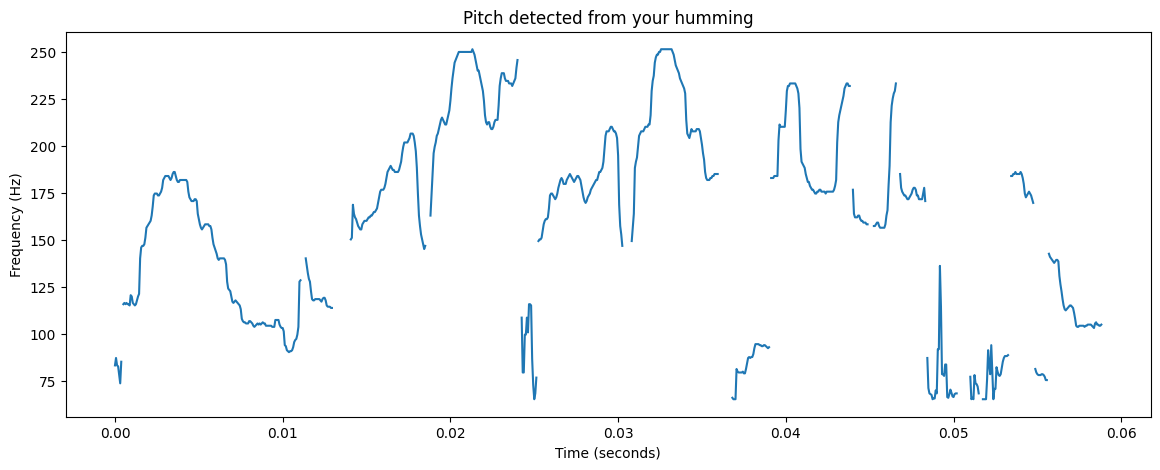

In [75]:
import matplotlib.pyplot as plt

times = np.arange(len(f0)) / sr

plt.figure(figsize=(14, 5))

plt.plot(times, f0)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.title("Pitch detected from your humming")

plt.show()

In [76]:
import librosa
import numpy as np

# ==========================================
# 1. Load audio
# ==========================================

audio, sr = librosa.load(
    "humming.wav",
    sr=16000,
    mono=True
)

print("Audio duration:", round(len(audio) / sr, 2), "seconds")


# ==========================================
# 2. Pitch detection
# ==========================================

HOP_LENGTH = 256
FRAME_LENGTH = 2048

f0, voiced_flag, voiced_probs = librosa.pyin(
    audio,

    # Lower range because your previous
    # detection was around C2-G3
    fmin=librosa.note_to_hz("C2"),
    fmax=librosa.note_to_hz("C6"),

    sr=sr,
    frame_length=FRAME_LENGTH,
    hop_length=HOP_LENGTH,

    # Make detection more tolerant
    fill_na=None
)


# ==========================================
# 3. Correct timestamps
# ==========================================

times = (
    np.arange(len(f0))
    * HOP_LENGTH
    / sr
)

print("Number of pitch frames:", len(f0))
print(
    "Last pitch timestamp:",
    round(times[-1], 2),
    "seconds"
)


# ==========================================
# 4. Inspect pitch detector
# ==========================================

valid = np.isfinite(f0)

print("\nPitch detector:")
print(
    "Frames with pitch:",
    np.sum(valid),
    "/",
    len(f0)
)

if np.any(valid):

    frequencies = f0[valid]

    print(
        "Minimum frequency:",
        round(np.min(frequencies), 2),
        "Hz"
    )

    print(
        "Maximum frequency:",
        round(np.max(frequencies), 2),
        "Hz"
    )

    print(
        "Median frequency:",
        round(np.median(frequencies), 2),
        "Hz"
    )

    print(
        "Median note:",
        librosa.midi_to_note(
            round(
                librosa.hz_to_midi(
                    np.median(frequencies)
                )
            )
        )
    )

else:

    print("❌ PYIN detected no pitch at all.")


# ==========================================
# 5. Convert ALL detected pitch to MIDI
# ==========================================

midi_track = []

for time, frequency in zip(times, f0):

    if np.isfinite(frequency):

        midi_note = round(
            librosa.hz_to_midi(frequency)
        )

        midi_track.append(
            (time, midi_note)
        )


# ==========================================
# 6. Smooth notes
# ==========================================

if len(midi_track) == 0:

    print("\n❌ No pitch detected.")

else:

    note_times = np.array(
        [x[0] for x in midi_track]
    )

    notes = np.array(
        [x[1] for x in midi_track]
    )


    filtered_notes = notes.copy()

    WINDOW = 7

    for i in range(len(notes)):

        start = max(
            0,
            i - WINDOW // 2
        )

        end = min(
            len(notes),
            i + WINDOW // 2 + 1
        )

        filtered_notes[i] = round(
            np.median(notes[start:end])
        )


    # ==========================================
    # 7. Group notes
    # ==========================================

    groups = []

    start_time = note_times[0]
    current_note = filtered_notes[0]

    for time, note in zip(
        note_times[1:],
        filtered_notes[1:]
    ):

        if note != current_note:

            groups.append(
                (
                    start_time,
                    time,
                    current_note
                )
            )

            start_time = time
            current_note = note


    groups.append(
        (
            start_time,
            note_times[-1] + HOP_LENGTH / sr,
            current_note
        )
    )


    # ==========================================
    # 8. Remove tiny notes
    # ==========================================

    MIN_DURATION = 0.15

    cleaned_groups = []

    for start, end, note in groups:

        duration = end - start

        if duration >= MIN_DURATION:

            cleaned_groups.append(
                (
                    start,
                    end,
                    note
                )
            )


    # ==========================================
    # 9. Print melody
    # ==========================================

    print("\nDetected melody segments:\n")

    for start, end, note in cleaned_groups:

        duration = end - start

        print(
            f"{start:6.2f}s - "
            f"{end:6.2f}s | "
            f"{librosa.midi_to_note(note):4} | "
            f"{duration:.2f}s"
        )

Audio duration: 30.12 seconds
Number of pitch frames: 1883
Last pitch timestamp: 30.11 seconds

Pitch detector:
Frames with pitch: 1883 / 1883
Minimum frequency: 65.41 Hz
Maximum frequency: 251.26 Hz
Median frequency: 163.86 Hz
Median note: E3

Detected melody segments:

  0.24s -   0.72s | A♯2  | 0.48s
  0.94s -   1.10s | D♯3  | 0.16s
  1.17s -   1.46s | F3   | 0.29s
  1.46s -   2.22s | F♯3  | 0.77s
  2.22s -   2.51s | F3   | 0.29s
  2.58s -   2.98s | D♯3  | 0.40s
  3.12s -   3.41s | C♯3  | 0.29s
  3.55s -   3.84s | A♯2  | 0.29s
  3.89s -   4.90s | G♯2  | 1.01s
  5.01s -   5.17s | G♯2  | 0.16s
  5.18s -   5.47s | F♯2  | 0.29s
  6.02s -   6.64s | A♯2  | 0.62s
  6.70s -   7.15s | C2   | 0.45s
  7.38s -   7.70s | D♯3  | 0.32s
  7.70s -   8.05s | E3   | 0.35s
  8.05s -   8.26s | F3   | 0.21s
  8.26s -   8.74s | F♯3  | 0.48s
  8.74s -   8.94s | G3   | 0.21s
  8.94s -   9.15s | G♯3  | 0.21s
  9.36s -   9.55s | D3   | 0.19s
  9.79s -  10.18s | G♯3  | 0.38s
 10.35s -  11.07s | B3   | 0.72s
 1

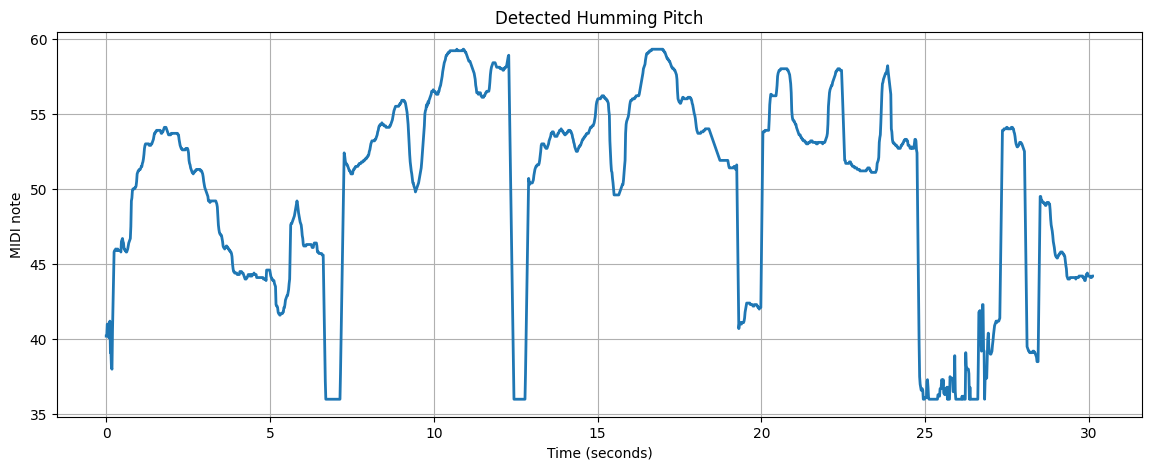

In [77]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

# Convert detected frequencies to MIDI
midi_f0 = np.full_like(f0, np.nan, dtype=float)

valid = np.isfinite(f0)

midi_f0[valid] = librosa.hz_to_midi(
    f0[valid]
)

# Plot
plt.figure(figsize=(14, 5))

plt.plot(
    times,
    midi_f0,
    linewidth=2
)

plt.xlabel("Time (seconds)")
plt.ylabel("MIDI note")
plt.title("Detected Humming Pitch")

plt.grid(True)

plt.show()

In [78]:
print("Detected MIDI range:")

valid_notes = midi_f0[np.isfinite(midi_f0)]

print(
    "Lowest:",
    librosa.midi_to_note(
        round(np.min(valid_notes))
    )
)

print(
    "Highest:",
    librosa.midi_to_note(
        round(np.max(valid_notes))
    )
)

Detected MIDI range:
Lowest: C2
Highest: B3


In [79]:
import pretty_midi
import numpy as np
import librosa

# ==========================================
# 1. Create MIDI
# ==========================================

midi = pretty_midi.PrettyMIDI()

# Acoustic piano
piano_program = pretty_midi.instrument_name_to_program(
    "Acoustic Grand Piano"
)

piano = pretty_midi.Instrument(
    program=piano_program
)


# ==========================================
# 2. Add detected melody notes
# ==========================================

for start, end, note in cleaned_groups:

    # Convert MIDI number to piano note
    midi_note = int(note)

    # Velocity
    velocity = 90

    piano_note = pretty_midi.Note(
        velocity=velocity,
        pitch=midi_note,
        start=float(start),
        end=float(end)
    )

    piano.notes.append(piano_note)


# ==========================================
# 3. Add piano to MIDI
# ==========================================

midi.instruments.append(piano)


# ==========================================
# 4. Save
# ==========================================

midi.write("humming_piano.mid")

print("🎹 MIDI created!")
print("File: humming_piano.mid")

🎹 MIDI created!
File: humming_piano.mid


In [44]:
!apt-get update -qq
!apt-get install -y fluidsynth -qq
!pip install -q pyfluidsynth pretty_midi

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)


In [58]:
!wget -q https://github.com/FluidSynth/fluidsynth/raw/master/test/20020206-FluidR3_GM.sf2 -O piano.sf2

In [80]:
import subprocess

subprocess.run([
    "fluidsynth",
    "-ni",
    "piano.sf2",
    "humming_piano.mid",
    "-F",
    "humming_piano.wav",
    "-r",
    "44100"
])

print("🎹 Piano audio created!")
print("File: humming_piano.wav")

🎹 Piano audio created!
File: humming_piano.wav


In [81]:
from IPython.display import Audio, display

display(
    Audio(
        "humming_piano.wav"
    )
)